<a href="https://colab.research.google.com/github/cfmiila/Agente_Triagem_Medica.ipynb/blob/main/GeoRoute.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# Data Structure: { "Origin": [("Destination", Weight_in_KM), ...] }


Phase 1: Building the Sparse Graph in RAM

In [1]:
graph = {

    "São Paulo": [("Campinas", 99), ("Santos", 72), ("Ribeirão Preto", 313), ("Feira de Santana", 1915)],
    "Campinas": [("São Paulo", 99), ("Ribeirão Preto", 225)],
    "Santos": [("São Paulo", 72)],
    "Ribeirão Preto": [("São Paulo", 313), ("Campinas", 225)],

    "Salvador": [("Camaçari", 50), ("Feira de Santana", 116)],
    "Camaçari": [("Salvador", 50), ("Feira de Santana", 85)],
    "Feira de Santana": [("Salvador", 116), ("Camaçari", 85), ("São Paulo", 1915)]
}

print(" Graph successfully loaded into RAM!")
print(f"Direct connections from Camaçari: {graph['Camaçari']}")

 Graph successfully loaded into RAM!
Direct connections from Camaçari: [('Salvador', 50), ('Feira de Santana', 85)]


Phase 2: Breadth-First Search (BFS)

In [3]:
from collections import deque

def bfs(graph, start, end):
    # The queue stores complete path arrays. Initialize with the starting node.
    queue = deque([[start]])
    visited = set() # O(1) lookups to prevent infinite cycles

    while queue:
        path = queue.popleft() # Extract the oldest path in O(1) time
        node = path[-1]        # The last node in the array is our current location

        if node == end:
            return path    # Target reached with the absolute minimum number of hops!

        if node in visited:
            continue
        visited.add(node)

        # Expand the frontier while ignoring edge weights completely
        for neighbor, _ in graph.get(node, []):
            if neighbor not in visited:
                # Allocate a new path array in RAM appending the neighbor
                queue.append(path + [neighbor])

    return None

# Execution Test:
bfs_route = bfs(graph, "Santos", "Feira de Santana")
print(f" BFS Route (Fewest Stops): {' → '.join(bfs_route)}")
print(f"Total Hops: {len(bfs_route) - 1}")

 BFS Route (Fewest Stops): Santos → São Paulo → Feira de Santana
Total Hops: 2


Phase 3: Dijkstra's Algorithm

In [ ]:
#The Engine (heapq): We replace the standard FIFO queue with a Min-Heap (Priority Queue). Python automatically sorts tuples based on their first element (the accumulated distance cost).
# Consequently, the shortest known trajectory always floats to the top of memory index 0 in $O(1)$ time.

In [4]:
import heapq

def dijkstra(graph, start, end):
    # The Min-Heap stores tuples: (accumulated_cost_in_km, complete_path_array)
    heap = [(0, [start])] # (custo_atual, caminho_atual)
    visited = {}

    while heap:
        cost, path = heapq.heappop(heap) # Always extracts the cheapest path in RAM
        node = path[-1]

        # Prune path if we previously found a cheaper route to this node
        if node in visited and visited[node] <= cost:
            continue
        visited[node] = cost

        if node == end:
            return cost, path # Return exact kilometer cost and optimal trajectory

        # Evaluate connecting highways and accumulate actual physical weights
        for neighbor, weight in graph.get(node, []):
            if neighbor not in visited or visited.get(neighbor, float('inf')) > cost + weight:
                heapq.heappush(heap, (cost + weight, path + [neighbor]))

    return float('inf'), []

# Execution Test:
dijkstra_cost, dijkstra_route = dijkstra(graph, "Santos", "Feira de Santana")
print(f" Dijkstra Route (Lowest KM): {' → '.join(dijkstra_route)}")
print(f"Total Distance Traversed: {dijkstra_cost} km")

 Dijkstra Route (Lowest KM): Santos → São Paulo → Feira de Santana
Total Distance Traversed: 1987 km


Phase 4: Graphical Visualization (NetworkX)

/tmp/ipykernel_3003/4003015667.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


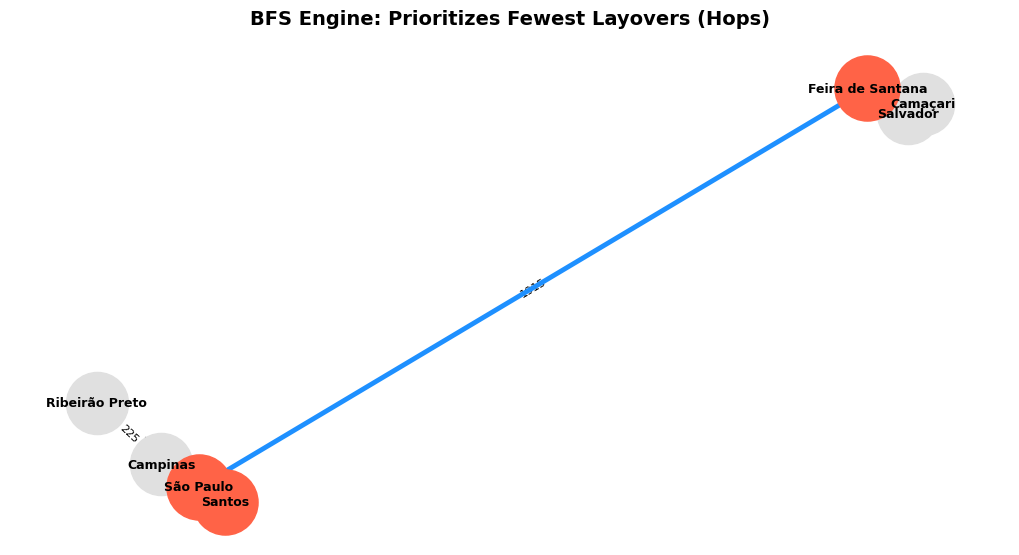

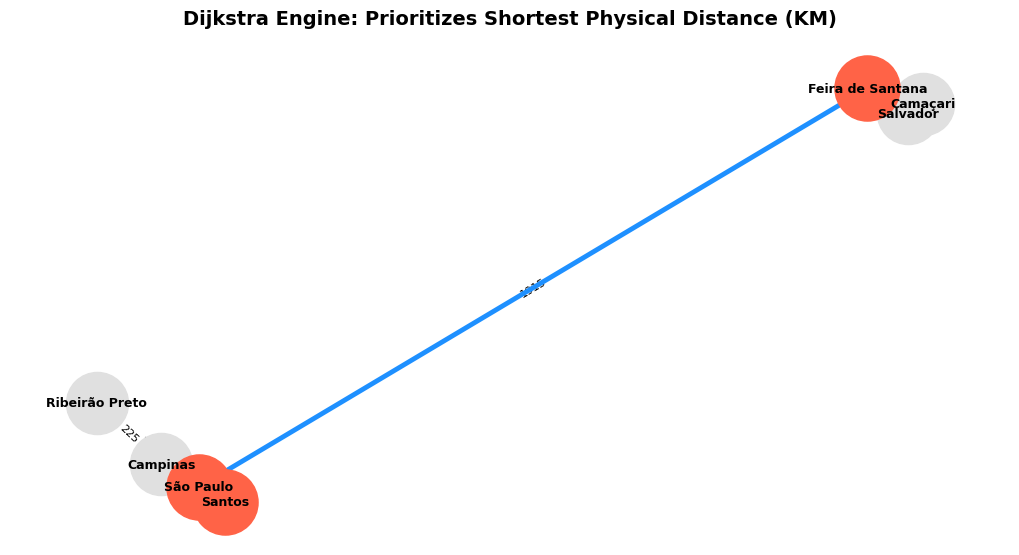

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

# 1 Spatial Coordinates Mapping (Longitude, Latitude)
pos = {
    "São Paulo":        (-46.63, -23.55),
    "Campinas":         (-47.06, -22.90),
    "Santos":           (-46.33, -23.96),
    "Ribeirão Preto":   (-47.80, -21.17),
    "Salvador":         (-38.50, -12.97),
    "Camaçari":         (-38.32, -12.69),
    "Feira de Santana": (-38.96, -12.26)
}

# 2 Build the visual graph instance
G = nx.Graph()
for city, neighbors in graph.items():
    for neighbor, weight in neighbors:
        G.add_edge(city, neighbor, weight=weight)

def draw_path(path_nodes, title):
    plt.figure(figsize=(10, 5))

    # Render base gray grid
    nx.draw(G, pos, with_labels=True, node_color="#E0E0E0", edge_color="#CCCCCC",
            node_size=2000, font_size=9, font_weight="bold")

    # Render physical weights alongside edges
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    # Highlight the computed optimal trajectory
    if path_nodes:
        path_edges = [(path_nodes[i], path_nodes[i+1]) for i in range(len(path_nodes)-1)]
        nx.draw_networkx_nodes(G, pos, nodelist=path_nodes, node_color="tomato", node_size=2200)
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color="dodgerblue", width=3.5)

    plt.title(title, fontsize=14, fontweight="bold", pad=15)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Render comparative maps:
draw_path(bfs_route, "BFS Engine: Prioritizes Fewest Layovers (Hops)")
draw_path(dijkstra_route, "Dijkstra Engine: Prioritizes Shortest Physical Distance (KM)")

Phase 5: A Search Algorithm*

🛰️ A* Route (GPS Guided): Santos → São Paulo → Feira de Santana


/tmp/ipykernel_3003/4003015667.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


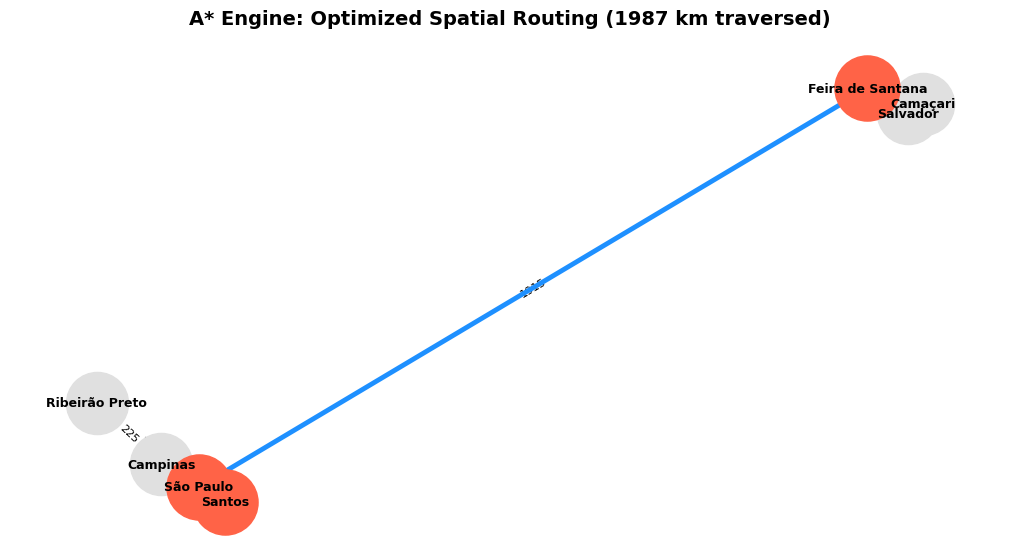

In [9]:
import math

def haversine(pos, a, b):
    # Apply Pythagoras theorem over GPS coordinates and convert degrees to KM (~111 km/degree)
    lon1, lat1 = pos[a]
    lon2, lat2 = pos[b]
    return math.sqrt((lat1 - lat2)**2 + (lon1 - lon2)**2) * 111

def a_star(graph, pos, start, end):
    # The Min-Heap stores tuples: (f_score, g_score, complete_path_array)
    heap = [(0, 0, [start])]
    visited = {}

    while heap:
        f, g, path = heapq.heappop(heap)
        node = path[-1]

        if node in visited and visited[node] <= g:
            continue
        visited[node] = g

        if node == end:
            return g, path # Return absolute optimal cost and trajectory

        for neighbor, weight in graph.get(node, []):
            new_g = g + weight
            if neighbor not in visited or visited.get(neighbor, float('inf')) > new_g:
                # The Core Upgrade: Calculate spatial straight-line distance heuristic
                h = haversine(pos, neighbor, end)
                # Push candidate to Heap sorted strictly by f = g + h
                heapq.heappush(heap, (new_g + h, new_g, path + [neighbor]))

    return float('inf'), []

# Execution Engine Test:
astar_cost, astar_route = a_star(graph, pos, "Santos", "Feira de Santana")
print(f"🛰️ A* Route (GPS Guided): {' → '.join(astar_route)}")
draw_path(astar_route, f"A* Engine: Optimized Spatial Routing ({astar_cost:.0f} km traversed)")